In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Olharemos Homicidios Dolosos 

1. Saber se e eiste PBM com muitos homicideos dolosos
2. Verificar se a uma média de hom dolosos atraves dos BPMs
3. Fazer uma visualização dos que estão muito acima dos demais 
4. Caso não aja muito acima dos demais, mostrar ranking de todos os BPSs
5. Mostre métricas de que sustentem que a média é confiavel 

In [10]:
try:
    # encoonding = 'latin1'
    # encomding = 'iso 8859-1'
    # enconding = 'IBM860'
    # enconding = 'utf-8'

    df_ocorrencias = pd.read_csv("03.BaseDPEvolucaoMensalCisp.csv", sep=';', encoding='iso 8859-1')
    df_bpm = pd.read_csv('08.BPM.csv', sep=';', encoding='utf-8')
    #print(df_ocorrencias.info())
    #print(df_bpm.info())
    # merge:
    # left_on -> qual coluna da tabela a esquerda vai ser o indicee para juntar com a da direita
    # right_on-> qual coluna da tabela da direita vai ser o indicee para juntar com a da esquerda
    # how -> o jeito que vai juntar as duas colunas:
    # how = right -> pega tudo da direita e copia o que tem combinação com a da esquerda
    # how = left -> pega tudo da esquerda e copia o que tem combinação com a da direita
    #how = outer-> pega tudo das duas tabelas
    df_merge = df_ocorrencias.merge(df_bpm,left_on='aisp', right_on='COD_BPM',how='left')
    df_doloso = df_merge[['aisp', 'NM_BPM', 'hom_doloso']]
    df_merge['COD_BPM'] = df_merge['COD_BPM'].astype(str)
    
    # fillna -> preenche as lacunas deixadas por inconsistencia de junção 
    df_doloso.fillna('BPM não encontrada', inplace=True)
    df_doloso_agrupado = df_doloso.groupby(['aisp', 'NM_BPM',]).sum().reset_index()
    print(df_doloso_agrupado)
  
    #df_merge.fillna('BPM não encontrado', inplace=True)

   
except Exception as e:
    print(f'Erro ao importar dados: {e}')

    aisp              NM_BPM  hom_doloso
0      1  BPM não encontrada         634
1      2              2º BPM         343
2      3              3º BPM        2624
3      4              4º BPM         780
4      5              5º BPM         723
5      6              6º BPM         794
6      7              7º BPM        7087
7      8              8º BPM        4495
8      9              9º BPM        5889
9     10             10º BPM        1082
10    11             11º BPM         953
11    12             12º BPM        3444
12    13  BPM não encontrada         108
13    14             14º BPM        4605
14    15             15º BPM        8474
15    16             16º BPM        2167
16    17             17º BPM         806
17    18             18º BPM        2184
18    19             19º BPM         193
19    20             20º BPM       10696
20    21             21º BPM        3278
21    22             22º BPM        1922
22    23             23º BPM         420
23    24        

In [12]:
# Calcular Metricas -> sispersção

doloso_array = np.array(df_doloso_agrupado['hom_doloso'])
q1 = np.quantile(doloso_array, 0.25)
q2 = np.quantile(doloso_array, 0.50)
q3 = np.quantile(doloso_array, 0.75)

media = np.mean(doloso_array)
desvio = np.std(doloso_array)
cv = desvio/media
delta = media/q2

In [16]:
# PREPARAÇÃO PARA O GRAFICO 

iqr = q3 -q1
limite_inf = q1 - 1.5 * iqr
limite_sup = q3 + 1.5 * iqr
# filtrar outliers
df_doloso_outilers_sup = df_doloso_agrupado[df_doloso_agrupado['hom_doloso'] > limite_sup]
df_doloso_outilers_inf = df_doloso_agrupado[df_doloso_agrupado['hom_doloso']< limite_inf]

df_grafico = None
if df_doloso_outilers_sup.empty: 
    df_grafico = df_doloso_agrupado.sort_values(by='hom_doloso', ascending=False)
    print(f'1. Não há BPMs com nuúero de homicídios dolosos muito maior que os outros')
else:
    df_grafico = df_doloso_outilers_sup
    print(f'1. Exixte {df_doloso_outilers_sup.shape[0]} BPMs com altos números de homicídios dolosos')


1. Exixte 2 BPMs com altos números de homicídios dolosos


2. Média:  2496.10
5. Mediana: 2175.50
5. Delta Média/mediana: 1.15
5. Desvio padrão: 2373.29
5. Coediciencia de variancia: 95.08% 


<function matplotlib.pyplot.show(close=None, block=None)>

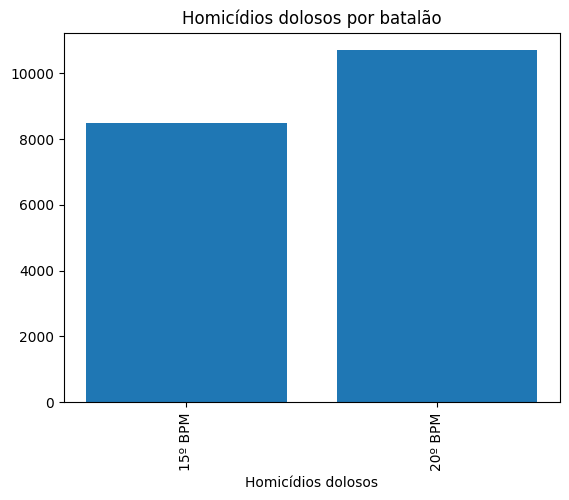

In [17]:
print(f'2. Média:  {media:.2f}')
print(f'5. Mediana: {q2:.2f}')
print(f'5. Delta Média/mediana: {delta:.2f}')
print(f'5. Desvio padrão: {desvio:.2f}')
print(f'5. Coediciencia de variancia: {cv*100:.2f}% ')

plt.bar(df_grafico['NM_BPM'], df_grafico['hom_doloso'])
plt.xticks(rotation=90)
plt.title('Homicídios dolosos por batalão')
plt.xlabel('Batalhoes')
plt.xlabel('Homicídios dolosos')
plt.show

